# AI Racer Training Progress

This notebook reads Data/Metrics/training_progress.csv and turns it into a readable training report: lap-time progression, fastest-lap updates, reward/loss trends, exploration state, checkpoints, and saved best-lap traces.

The goal is to make training progress easier to scan. Start with the summary table, then look at lap time for driving performance, and use reward, loss, epsilon, and replay buffer as supporting training-health signals. A single chart rarely tells the whole story, but together they make it much easier to see whether the driver is genuinely improving or just getting lucky once.


In [12]:
from pathlib import Path
import csv
import json
import math
import re

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 160,
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})


def resolve_project_path(*parts):
    candidates = [Path.cwd(), Path.cwd().parent]
    for root in candidates:
        path = root.joinpath(*parts)
        if path.exists():
            return path
    return candidates[0].joinpath(*parts)


METRICS_PATH = resolve_project_path("Data", "Metrics", "training_progress.csv")
TRACE_DIR = resolve_project_path("Data", "Runs", "lap-traces")
METRICS_PATH


WindowsPath('c:/Practice Challenge/AI-Racer-and-Game/Data/Metrics/training_progress.csv')

In [13]:
def number(value):
    if value in (None, ""):
        return None
    try:
        parsed = float(value)
    except (TypeError, ValueError):
        return None
    return parsed if math.isfinite(parsed) else None


def fmt(value, digits=3, suffix=""):
    value = number(value)
    if value is None:
        return "-"
    if abs(value) >= 1000:
        text = f"{value:,.0f}"
    else:
        text = f"{value:.{digits}f}".rstrip("0").rstrip(".")
    return f"{text}{suffix}"


def load_rows(path):
    if not path.exists():
        return []
    with path.open(newline="", encoding="utf-8") as file:
        return list(csv.DictReader(file))


def step_points(source_rows, field):
    points = []
    for row in source_rows:
        step = number(row.get("step"))
        value = number(row.get(field))
        if step is not None and value is not None:
            points.append((step, value))
    return points


def moving_average(points, window=8):
    averaged = []
    values = []
    for step, value in points:
        values.append(value)
        sample = values[-window:]
        averaged.append((step, sum(sample) / len(sample)))
    return averaged


def lap_time_candidates(rows):
    lap_rows = [
        row for row in rows
        if row.get("event") == "lap" and row.get("metric") == "lap_time" and number(row.get("metric_value")) is not None
    ]
    if lap_rows:
        return lap_rows, "all logged laps"
    checkpoint_rows = [
        row for row in rows
        if row.get("event") == "checkpoint" and row.get("metric") == "lap_time" and number(row.get("metric_value")) is not None
    ]
    return checkpoint_rows, "fastest-lap checkpoints"


def derive_laps(rows):
    source_rows, source_label = lap_time_candidates(rows)
    laps = []
    best = math.inf
    for row in source_rows:
        step = number(row.get("step"))
        lap_time = number(row.get("metric_value"))
        if step is None or lap_time is None:
            continue
        reason = row.get("reason") or ""
        marked_record = "best" in reason.lower() or "fastest" in reason.lower()
        is_record = marked_record or lap_time < best - 0.0005
        previous_best = best if math.isfinite(best) else None
        best = min(best, lap_time, number(row.get("best_lap_time")) or lap_time)
        laps.append({
            "step": step,
            "lap_time": lap_time,
            "best_lap_time": best,
            "previous_best": previous_best,
            "improvement": (previous_best - lap_time) if previous_best is not None and lap_time < previous_best else None,
            "is_record": is_record,
            "reason": reason,
            "event": row.get("event") or "",
        })
    return laps, source_label


def load_trace_summaries(directory):
    summaries = []
    if not directory.exists():
        return summaries
    for path in sorted(directory.glob("*.lap-trace.json")):
        try:
            trace = json.loads(path.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            continue
        lap_time = number(trace.get("lapTime"))
        if lap_time is None:
            continue
        match = re.search(r"episode-(\d+)-lap-(\d+)", path.name)
        episode = int(match.group(1)) if match else None
        filename_lap = int(match.group(2)) if match else None
        summaries.append({
            "file": path.name,
            "lap_time": lap_time,
            "episode": episode,
            "lap": trace.get("lap") if trace.get("lap") is not None else filename_lap,
            "created_at": trace.get("createdAt", ""),
            "points": len(trace.get("points", [])),
        })
    return sorted(summaries, key=lambda item: item["lap_time"])


rows = load_rows(METRICS_PATH)
intervals = [row for row in rows if row.get("event") == "interval"]
checkpoints = [row for row in rows if row.get("event") == "checkpoint"]
laps, lap_source_label = derive_laps(rows)
trace_summaries = load_trace_summaries(TRACE_DIR)
trace_records = sorted(
    trace_summaries,
    key=lambda item: (item["episode"] if item["episode"] is not None else math.inf, item["lap"] or math.inf, item["created_at"]),
)
latest = rows[-1] if rows else {}
latest_interval = intervals[-1] if intervals else {}
records = [lap for lap in laps if lap["is_record"]]


In [14]:
COLORS = {
    "purple": "#725cff",
    "green": "#12a574",
    "blue": "#00b8df",
    "red": "#e43d52",
    "gray": "#5d6677",
    "yellow": "#d8b300",
}


def markdown_table(headers, body_rows):
    table = ["| " + " | ".join(headers) + " |", "| " + " | ".join(["---"] * len(headers)) + " |"]
    for row in body_rows:
        table.append("| " + " | ".join(str(cell) for cell in row) + " |")
    display(Markdown("\n".join(table)))


def unpack(points):
    return [point[0] for point in points], [point[1] for point in points]


def style_axis(ax, title, subtitle="", xlabel="step", ylabel=""):
    ax.set_title(title, loc="left", fontweight="bold", pad=12)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, ha="left", va="bottom", fontsize=9, color=COLORS["gray"])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True, color="#d8e1ec", linewidth=0.8)
    ax.ticklabel_format(axis="x", style="plain", useOffset=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def plot_lines(title, series, markers=None, xlabel="step", ylabel="", subtitle="", figsize=(9.4, 3.5)):
    series = [item for item in series if item["points"]]
    if not series:
        display(Markdown(f"No data yet for **{title}**."))
        return

    fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
    for item in series:
        xs, ys = unpack(item["points"])
        ax.plot(
            xs,
            ys,
            color=item["color"],
            label=item["label"],
            linewidth=item.get("linewidth", 2.2),
            linestyle="--" if item.get("dash") else "-",
            marker=item.get("marker", None),
            markersize=item.get("markersize", 4),
        )

    markers = markers or []
    for marker in markers:
        ax.scatter(
            [marker["x"]],
            [marker["y"]],
            s=marker.get("size", 70),
            color=marker.get("color", COLORS["yellow"]),
            edgecolors="#10131a",
            linewidths=0.8,
            zorder=5,
        )
    if 0 < len(markers) <= 8:
        for marker in markers:
            ax.annotate(
                marker.get("text", "new fastest"),
                (marker["x"], marker["y"]),
                textcoords="offset points",
                xytext=(6, 8),
                fontsize=8,
                color="#10131a",
            )

    style_axis(ax, title, subtitle, xlabel, ylabel)
    ax.legend(loc="best", frameon=True)
    plt.show()


## Quick Read

This table is the fast status check. Metric rows and latest step tell you how much training history was loaded. Fastest lap and improvement are the driver-performance numbers. Mean reward, loss, epsilon, and replay buffer are training signals that help explain why the driver may be improving, stalling, or behaving inconsistently.


In [15]:
if not rows:
    display(Markdown(f"No metrics yet at {METRICS_PATH}. Start python ai_service/server.py, then run npx tsx scripts/headless.ts."))
else:
    best_lap = min((lap["lap_time"] for lap in laps), default=number(latest.get("best_lap_time")))
    first_lap = laps[0]["lap_time"] if laps else None
    improvement = (first_lap - best_lap) if first_lap is not None and best_lap is not None else None
    summary_rows = [
        ("Metric rows", f"{len(rows):,}", f"loaded from {METRICS_PATH.name}"),
        ("Latest step", fmt(latest.get("step"), 0), f"epsilon {fmt(latest.get('epsilon'), 3)}"),
        ("Fastest lap", fmt(best_lap, 3, "s"), f"{len(records)} fastest-lap update(s)"),
        ("Lap source", lap_source_label, f"{len(laps)} lap point(s) plotted"),
        ("Mean reward", fmt(latest_interval.get("mean_reward"), 4), "latest interval"),
        ("Loss", fmt(latest_interval.get("loss"), 4), "latest interval"),
        ("Replay buffer", fmt(latest_interval.get("buffer_size"), 0), "latest interval"),
        ("Improvement", fmt(improvement, 3, "s"), "first plotted lap to fastest"),
    ]
    markdown_table(["metric", "value", "what it means"], summary_rows)
    if lap_source_label == "fastest-lap checkpoints":
        display(Markdown(
            "This CSV predates per-lap logging, so the lap chart shows saved fastest-lap checkpoints only. "
            "After the trainer writes lap rows, the same chart will show every completed lap and highlight each new record."
        ))


| metric | value | what it means |
| --- | --- | --- |
| Metric rows | 2,431 | loaded from training_progress.csv |
| Latest step | 1,087,000 | epsilon 0.05 |
| Fastest lap | 6.067s | 19 fastest-lap update(s) |
| Lap source | all logged laps | 1152 lap point(s) plotted |
| Mean reward | -1.0415 | latest interval |
| Loss | 2.5989 | latest interval |
| Replay buffer | 50,000 | latest interval |
| Improvement | 2.067s | first plotted lap to fastest |

## Lap Times

This is the main driving-performance view. The purple line is the lap time recorded at each training step, and lower is better. The green line is the best lap time seen so far, so it should either move downward or stay flat. Yellow points mark moments where the driver found a new fastest lap.

If the chart only has a few points, that usually means the current CSV only has checkpoint saves, not every completed lap. Once the trainer logs per-lap rows, this same view becomes a fuller lap-by-lap history.


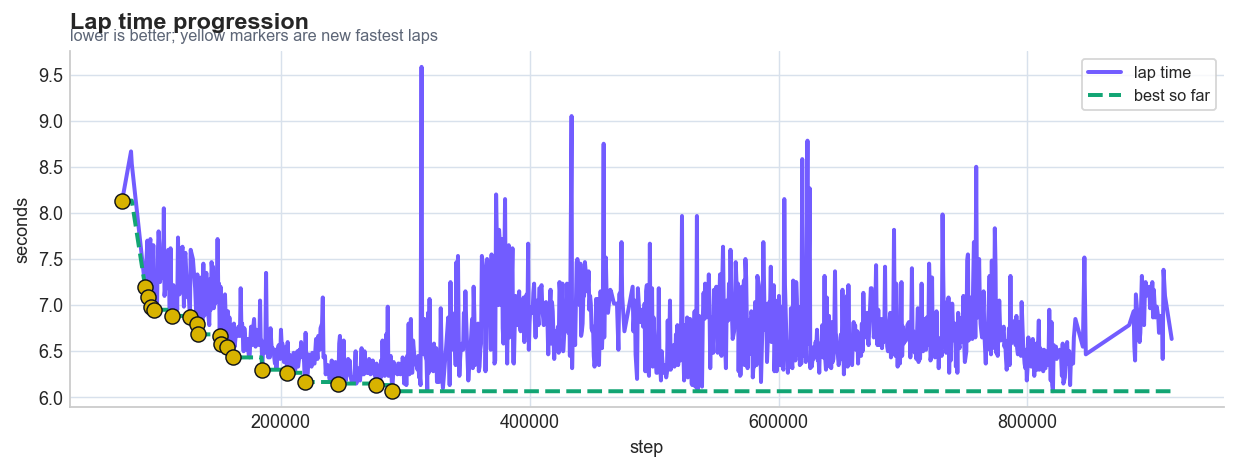

In [16]:
if laps:
    lap_points = [(lap["step"], lap["lap_time"]) for lap in laps]
    best_points = [(lap["step"], lap["best_lap_time"]) for lap in laps]
    markers = [
        {
            "x": lap["step"],
            "y": lap["lap_time"],
            "text": f"{lap['lap_time']:.3f}s",
        }
        for lap in laps if lap["is_record"]
    ]
    plot_lines(
        "Lap time progression",
        [
            {"label": "lap time", "color": COLORS["purple"], "points": lap_points, "marker": "o" if len(lap_points) <= 20 else None},
            {"label": "best so far", "color": COLORS["green"], "points": best_points, "dash": True},
        ],
        markers=markers,
        ylabel="seconds",
        subtitle="lower is better; yellow markers are new fastest laps",
    )
else:
    display(Markdown("No completed lap times have been logged yet."))


## Saved Fastest-Lap Traces

These points come from the saved lap-trace JSON files, which are kept whenever training finds a better lap. This is useful when the CSV is sparse because the trace files still preserve the best-lap story. The file also contains the path points, so it can be inspected later on the track view if you want to see how the driver actually drove the lap.


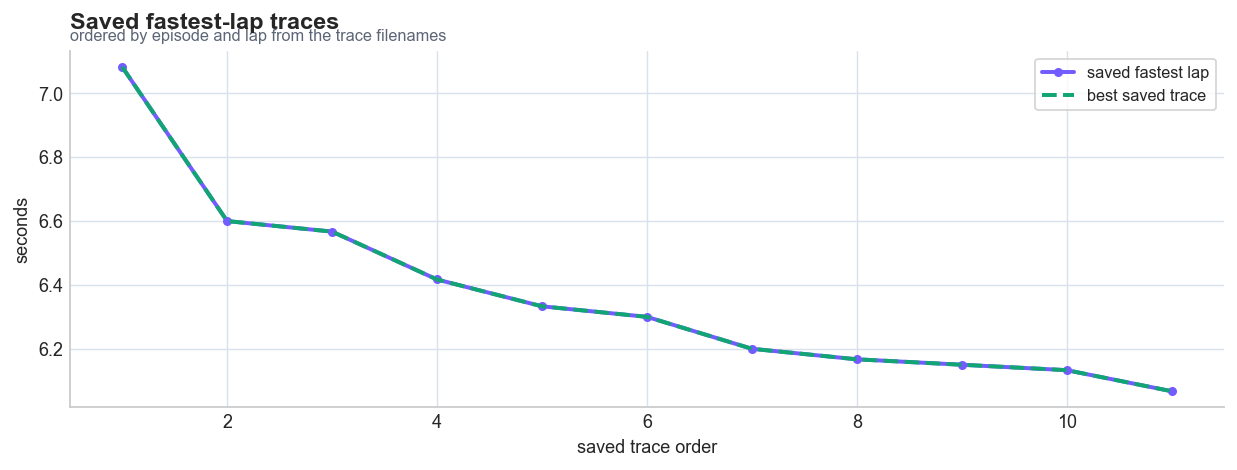

In [17]:
if trace_records:
    trace_points = []
    trace_best_points = []
    trace_markers = []
    best_trace = math.inf
    for index, trace in enumerate(trace_records, start=1):
        best_trace = min(best_trace, trace["lap_time"])
        trace_points.append((index, trace["lap_time"]))
        trace_best_points.append((index, best_trace))
        trace_markers.append({
            "x": index,
            "y": trace["lap_time"],
            "text": f"{trace['lap_time']:.3f}s",
            "size": 55,
        })
    plot_lines(
        "Saved fastest-lap traces",
        [
            {"label": "saved fastest lap", "color": COLORS["purple"], "points": trace_points, "marker": "o"},
            {"label": "best saved trace", "color": COLORS["green"], "points": trace_best_points, "dash": True},
        ],
        markers=trace_markers if len(trace_markers) <= 10 else [],
        xlabel="saved trace order",
        ylabel="seconds",
        subtitle="ordered by episode and lap from the trace filenames",
    )
else:
    display(Markdown("No saved fastest-lap traces are available yet."))


## Training Health

Reward, loss, epsilon, and replay buffer are not lap-time results by themselves. They explain the learning process around the driving. Mean reward should generally improve when the driver makes cleaner progress. Loss shows how hard the model is adjusting to recent experience. Epsilon shows how much random exploration is still happening. Replay buffer size shows how much experience the model has available to learn from.

Read these together with lap time. A better reward without faster laps can mean the driver is safer but not quicker yet. A faster lap with unstable reward or loss can mean the model found something promising but has not made it reliable.


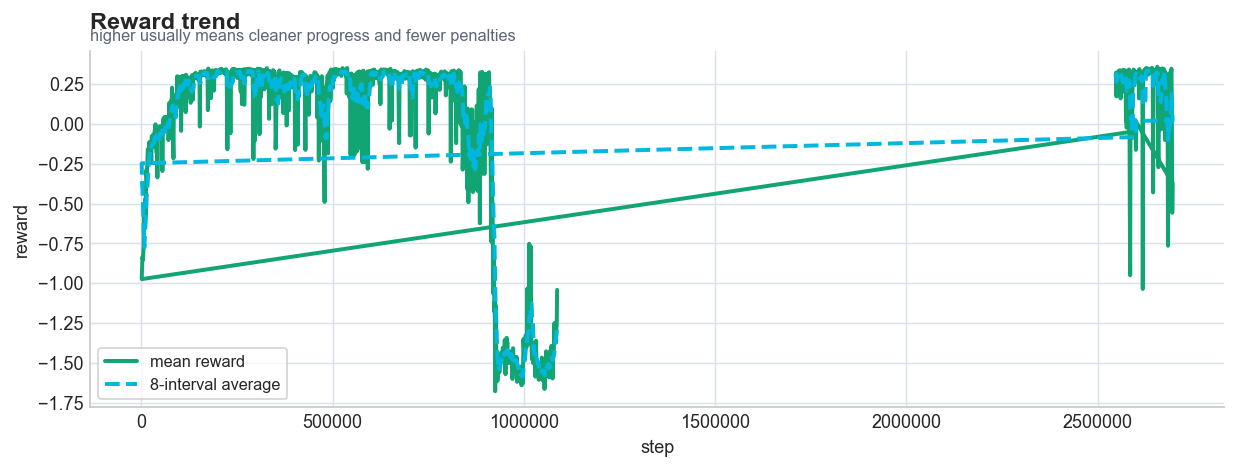

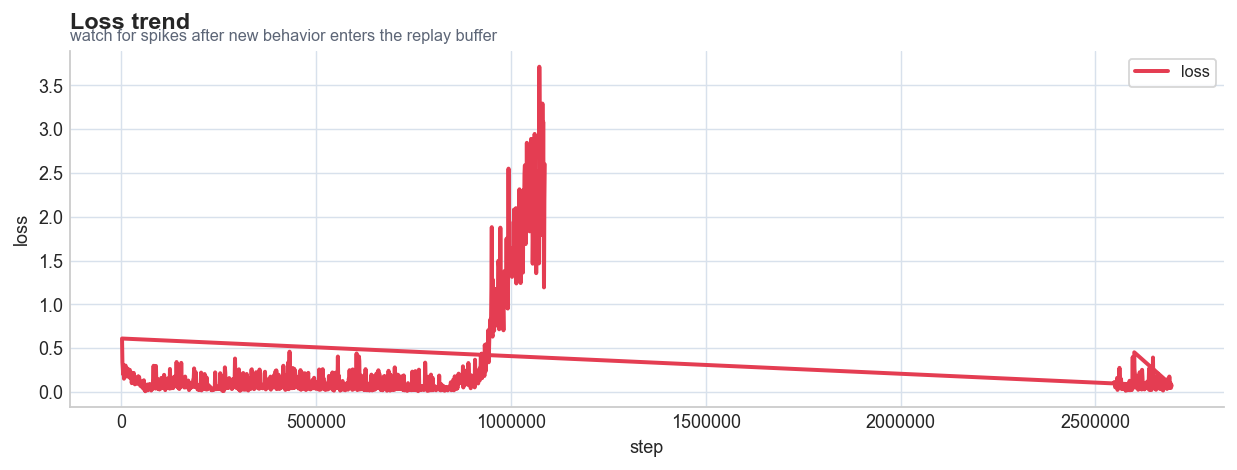

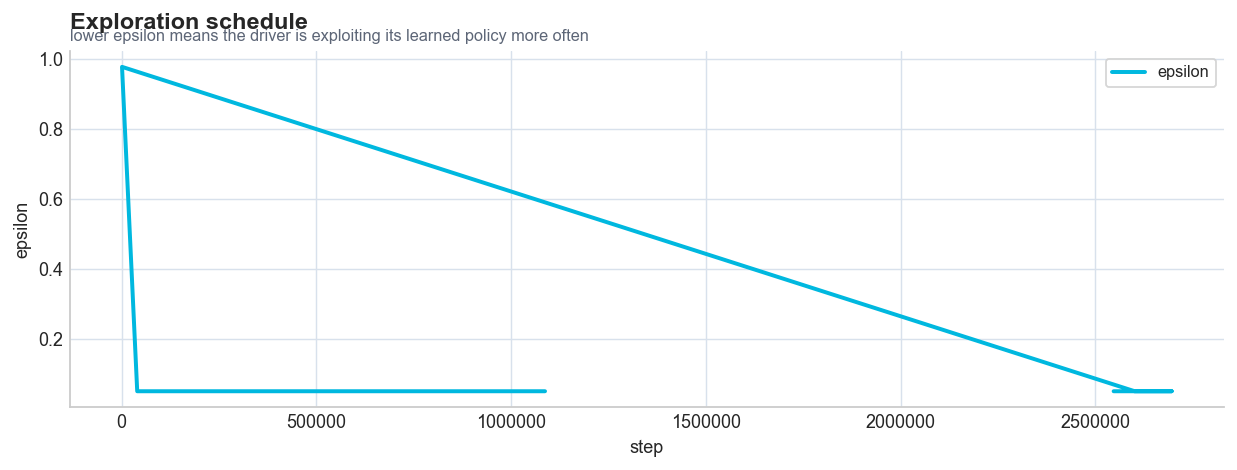

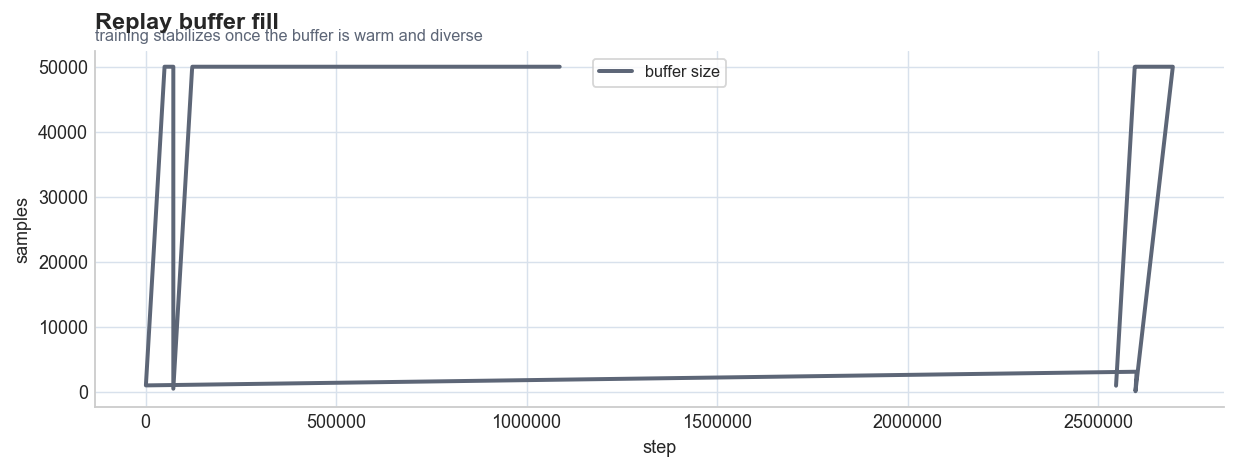

In [18]:
reward_points = step_points(intervals, "mean_reward")
loss_points = step_points(intervals, "loss")
epsilon_points = step_points(intervals, "epsilon")
buffer_points = step_points(intervals, "buffer_size")

plot_lines(
    "Reward trend",
    [
        {"label": "mean reward", "color": COLORS["green"], "points": reward_points},
        {"label": "8-interval average", "color": COLORS["blue"], "points": moving_average(reward_points, 8), "dash": True},
    ],
    ylabel="reward",
    subtitle="higher usually means cleaner progress and fewer penalties",
)
plot_lines(
    "Loss trend",
    [{"label": "loss", "color": COLORS["red"], "points": loss_points}],
    ylabel="loss",
    subtitle="watch for spikes after new behavior enters the replay buffer",
)
plot_lines(
    "Exploration schedule",
    [{"label": "epsilon", "color": COLORS["blue"], "points": epsilon_points}],
    ylabel="epsilon",
    subtitle="lower epsilon means the driver is exploiting its learned policy more often",
)
plot_lines(
    "Replay buffer fill",
    [{"label": "buffer size", "color": COLORS["gray"], "points": buffer_points}],
    ylabel="samples",
    subtitle="training stabilizes once the buffer is warm and diverse",
)


## Details And Saved Artifacts

The tables are the audit trail. Fastest-lap updates show exactly when the driver improved and by how much. Checkpoint saves show why the model was written to disk. Saved trace files list the concrete lap artifacts you can load elsewhere to inspect the path, speed samples, and off-track behavior.


In [19]:
if records:
    record_rows = []
    for lap in records[-12:]:
        improvement = fmt(lap["improvement"], 3, "s") if lap["improvement"] is not None else "first record"
        record_rows.append([
            f"{lap['step']:,.0f}",
            f"{lap['lap_time']:.3f}s",
            improvement,
            lap["reason"] or lap["event"],
        ])
    display(Markdown("### Fastest-lap updates"))
    markdown_table(["step", "lap time", "improvement", "why"], record_rows)
else:
    display(Markdown("No fastest-lap updates are available yet."))

if checkpoints:
    checkpoint_rows = []
    for row in checkpoints[-10:]:
        checkpoint_rows.append([
            fmt(row.get("step"), 0),
            row.get("reason", ""),
            row.get("metric", ""),
            fmt(row.get("metric_value"), 3),
        ])
    display(Markdown("### Recent checkpoint saves"))
    markdown_table(["step", "reason", "metric", "value"], checkpoint_rows)

if trace_summaries:
    trace_rows = []
    for trace in trace_summaries[:10]:
        trace_rows.append([
            f"{trace['lap_time']:.3f}s",
            trace.get("episode", ""),
            trace.get("lap", ""),
            trace["points"],
            trace["created_at"][:19],
            trace["file"],
        ])
    display(Markdown("### Saved fastest-lap traces"))
    markdown_table(["lap time", "episode", "lap", "points", "created", "file"], trace_rows)
else:
    display(Markdown("No saved lap trace files found."))


### Fastest-lap updates

| step | lap time | improvement | why |
| --- | --- | --- | --- |
| 132,340 | 6.800s | 0.067s | new fastest lap |
| 133,533 | 6.683s | 0.117s | new fastest lap |
| 150,933 | 6.667s | 0.017s | new fastest lap |
| 152,127 | 6.583s | 0.083s | new fastest lap |
| 156,925 | 6.550s | 0.033s | new fastest lap |
| 161,718 | 6.433s | 0.117s | new fastest lap |
| 185,109 | 6.300s | 0.133s | new fastest lap |
| 204,910 | 6.267s | 0.033s | new fastest lap |
| 219,303 | 6.167s | 0.1s | new fastest lap |
| 246,301 | 6.150s | 0.017s | new fastest lap |
| 276,300 | 6.133s | 0.017s | new fastest lap |
| 289,496 | 6.067s | 0.067s | new fastest lap |

### Recent checkpoint saves

| step | reason | metric | value |
| --- | --- | --- | --- |
| 150,933 | new best lap time | lap_time | 6.667 |
| 152,127 | new best lap time | lap_time | 6.583 |
| 156,925 | new best lap time | lap_time | 6.55 |
| 161,718 | new best lap time | lap_time | 6.433 |
| 185,109 | new best lap time | lap_time | 6.3 |
| 204,910 | new best lap time | lap_time | 6.267 |
| 219,303 | new best lap time | lap_time | 6.167 |
| 246,301 | new best lap time | lap_time | 6.15 |
| 276,300 | new best lap time | lap_time | 6.133 |
| 289,496 | new best lap time | lap_time | 6.067 |

### Saved fastest-lap traces

| lap time | episode | lap | points | created | file |
| --- | --- | --- | --- | --- | --- |
| 6.067s | 362 | 1 | 104 | 2026-06-09T01:15:39 | fastest-lap-006067ms-episode-362-lap-1.lap-trace.json |
| 6.133s | 340 | 1 | 106 | 2026-06-09T01:14:46 | fastest-lap-006133ms-episode-340-lap-1.lap-trace.json |
| 6.150s | 18 | 2 | 105 | 2026-06-04T15:07:45 | fastest-lap-006150ms-episode-18-lap-2.lap-trace.json |
| 6.167s | 16 | 4 | 109 | 2026-06-04T15:07:29 | fastest-lap-006167ms-episode-16-lap-4.lap-trace.json |
| 6.200s | 12 | 7 | 104 | 2026-06-04T15:06:57 | fastest-lap-006200ms-episode-12-lap-7.lap-trace.json |
| 6.300s | 11 | 3 | 106 | 2026-06-04T15:06:42 | fastest-lap-006300ms-episode-11-lap-3.lap-trace.json |
| 6.333s | 5 | 6 | 107 | 2026-06-04T15:05:53 | fastest-lap-006333ms-episode-5-lap-6.lap-trace.json |
| 6.417s | 5 | 2 | 109 | 2026-06-04T15:05:46 | fastest-lap-006417ms-episode-5-lap-2.lap-trace.json |
| 6.567s | 1 | 6 | 109 | 2026-06-04T15:05:15 | fastest-lap-006567ms-episode-1-lap-6.lap-trace.json |
| 6.600s | 1 | 2 | 113 | 2026-06-04T15:05:10 | fastest-lap-006600ms-episode-1-lap-2.lap-trace.json |

## Racing Line Evolution

The charts above are numbers; this section draws the **actual paths the car drove**. Every saved lap-trace JSON stores the `(x, y)` positions of one lap, so we can replay them on the track. Each saved trace is a new fastest lap, so plotting them in the order they were found shows the racing line getting tighter and faster as training progresses.

Colour encodes that order: **red is the earliest saved best, green is the latest**. Watch where red and green diverge — that is where the driver learned to brake later, carry more speed, or take a tighter apex. This is the view that catches a model driving a *better line*, which a lap-time number alone can hide.

In [20]:
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# The track the headless trainer drives (scripts/headless.ts imports track-2).
# Point this at another Data/Tracks/*.track.json if you train on a different one.
TRACK_PATH = resolve_project_path("Data", "Tracks", "track-2.track.json")
RUNS_DIR = resolve_project_path("Data", "Runs")

# Distinct hues for overlaying whole runs against each other (reuse the palette above).
RUN_COLORS = [COLORS["purple"], COLORS["green"], COLORS["blue"], COLORS["red"], COLORS["yellow"]]


def load_track(path):
    return json.loads(path.read_text(encoding="utf-8"))


def track_geometry(track):
    """Centerline plus left/right edges, mirroring compileTrack's linear segments
    and rightNormal(t) = (-t.y, t.x) so the drawn road matches what the simulator used."""
    pts = np.array([(point["x"], point["y"]) for point in track["centerline"]], dtype=float)
    n = len(pts)
    global_width = float(track.get("globalWidth", 100))
    half = np.array([float(point.get("width", global_width)) for point in track["centerline"]]) / 2.0

    seg_normal = np.zeros((n, 2))
    for i in range(n):
        tangent = pts[(i + 1) % n] - pts[i]
        length = math.hypot(tangent[0], tangent[1])
        tangent = tangent / length if length > 1e-6 else np.array([1.0, 0.0])
        seg_normal[i] = (-tangent[1], tangent[0])

    left = np.zeros((n, 2))
    right = np.zeros((n, 2))
    for i in range(n):
        miter = seg_normal[(i - 1) % n] + seg_normal[i]
        miter_len = math.hypot(miter[0], miter[1])
        if miter_len < 1e-6:
            unit, scale = seg_normal[i], 1.0
        else:
            unit = miter / miter_len
            scale = 1.0 / max(float(np.dot(unit, seg_normal[i])), 0.25)  # clamp so sharp corners don't spike
        offset = unit * half[i] * scale
        left[i] = pts[i] + offset
        right[i] = pts[i] - offset
    return pts, left, right


def draw_track(ax, track):
    pts, left, right = track_geometry(track)
    n = len(pts)
    for i in range(n):  # tile the road as per-segment quads so the closed loop fills cleanly
        quad = np.array([left[i], left[(i + 1) % n], right[(i + 1) % n], right[i]])
        ax.fill(quad[:, 0], quad[:, 1], color="#e9eef5", zorder=0, linewidth=0)
    for edge in (left, right):
        loop = np.vstack([edge, edge[0]])
        ax.plot(loop[:, 0], loop[:, 1], color="#9aa7ba", linewidth=1.1, zorder=1)
    center = np.vstack([pts, pts[0]])
    ax.plot(center[:, 0], center[:, 1], color="#c2ccda", linewidth=0.8, linestyle=(0, (6, 6)), zorder=1)
    ax.set_aspect("equal")
    ax.invert_yaxis()  # world Y points down, like the on-screen canvas
    ax.axis("off")


def load_run_traces(directory):
    """Saved lap traces in a run folder, sorted into training order (episode, then
    lap). Each saved trace is a new fastest lap, so this is also worst-to-best."""
    traces = []
    for path in sorted(directory.glob("*.lap-trace.json")):
        try:
            trace = json.loads(path.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            continue
        if not trace.get("points"):
            continue
        match = re.search(r"episode-(\d+)-lap-(\d+)", path.name)
        trace["_episode"] = int(match.group(1)) if match else None
        trace["_file"] = path.name
        traces.append(trace)
    traces.sort(key=lambda trace: (
        trace["_episode"] if trace["_episode"] is not None else math.inf,
        number(trace.get("lap")) if number(trace.get("lap")) is not None else math.inf,
        trace.get("createdAt", ""),
    ))
    return traces


def discover_runs(runs_dir):
    """Every subfolder of Data/Runs that holds lap traces is one training run.
    Set RUN_NAME when running scripts/headless.ts to create new ones."""
    runs = {}
    if runs_dir.exists():
        for child in sorted(runs_dir.iterdir()):
            if child.is_dir():
                traces = load_run_traces(child)
                if traces:
                    runs[child.name] = traces
    return runs


def trace_xy(trace):
    points = trace["points"]
    return [point["x"] for point in points], [point["y"] for point in points]


def legend_label(name):
    return name.lstrip("_") or name  # matplotlib hides labels starting with "_"


RUNS = discover_runs(RUNS_DIR)
TRACK = load_track(TRACK_PATH) if TRACK_PATH.exists() else None

# Fail loud if the saved traces don't all come from the track we're about to draw.
trace_hashes = {trace.get("trackHash") for traces in RUNS.values() for trace in traces}
if not RUNS:
    display(Markdown(f"No lap traces found under `{RUNS_DIR}`. Run `npx tsx scripts/headless.ts` to record some."))
elif TRACK is None:
    display(Markdown(f"Track file not found at `{TRACK_PATH}`; the maps need it to draw the road."))
elif len([h for h in trace_hashes if h]) > 1:
    display(Markdown(
        f"Heads up: saved traces span multiple track hashes {sorted(h for h in trace_hashes if h)}. "
        f"The map is drawn for `{TRACK_PATH.name}`, so runs recorded on a different track may not line up."
    ))
else:
    display(Markdown(
        f"Loaded {sum(len(v) for v in RUNS.values())} saved lap trace(s) across "
        f"{len(RUNS)} run(s): {', '.join(RUNS)} — drawing on `{TRACK_PATH.name}`."
    ))


Loaded 11 saved lap trace(s) across 1 run(s): lap-traces — drawing on `track-2.track.json`.

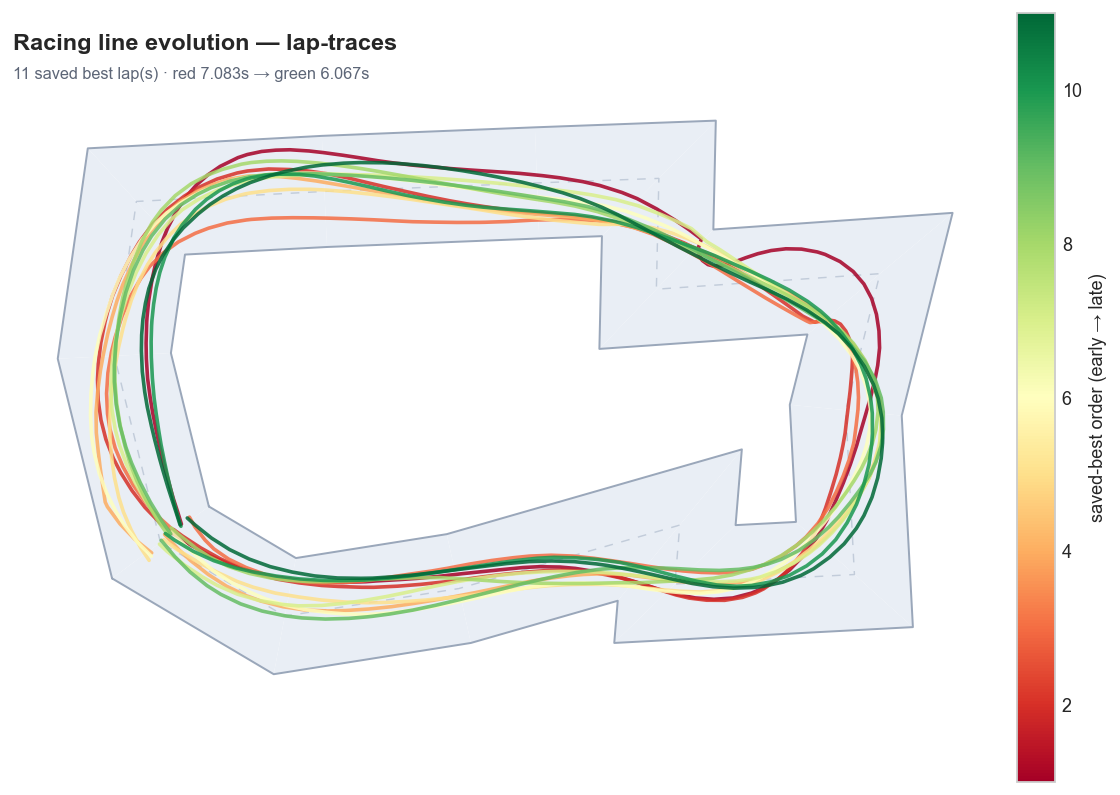

In [21]:
def plot_evolution(ax, track, traces):
    """Draw the track, then every saved best lap coloured red (earliest) to green
    (latest) so the racing line's improvement over training is visible at a glance."""
    draw_track(ax, track)
    cmap = plt.get_cmap("RdYlGn")
    count = len(traces)
    for index, trace in enumerate(traces):
        frac = index / (count - 1) if count > 1 else 1.0
        x, y = trace_xy(trace)
        ax.plot(x, y, color=cmap(frac), linewidth=2.0, alpha=0.85,
                solid_capstyle="round", zorder=2 + index)
    return cmap, count


if RUNS and TRACK is not None:
    for name, traces in RUNS.items():
        fig, ax = plt.subplots(figsize=(8.5, 6), constrained_layout=True)
        cmap, count = plot_evolution(ax, TRACK, traces)
        scalar = ScalarMappable(cmap=cmap, norm=Normalize(vmin=1, vmax=max(count, 2)))
        bar = fig.colorbar(scalar, ax=ax, fraction=0.04, pad=0.02)
        bar.set_label("saved-best order (early → late)")
        earliest = traces[0]
        fastest = min(traces, key=lambda trace: number(trace.get("lapTime")) or math.inf)
        ax.set_title(f"Racing line evolution — {name}", loc="left", fontweight="bold", pad=24)
        ax.annotate(
            f"{count} saved best lap(s) · red {fmt(earliest.get('lapTime'), 3, 's')} → green {fmt(fastest.get('lapTime'), 3, 's')}",
            xy=(0, 1), xycoords="axes fraction", xytext=(0, 6), textcoords="offset points",
            fontsize=9, color=COLORS["gray"], va="bottom", ha="left",
        )
        plt.show()
else:
    display(Markdown("No recorded lap traces to draw yet."))


## Model Comparison

This is the section for "did my change help?" — for example after changing how the car's vision works. Each training run lives in its own folder under `Data/Runs/` (set `RUN_NAME=my-change` when running `scripts/headless.ts`), and the views below line them up.

Read them together. **Lap time by run** answers the clock question: is the new model faster, and did it get there sooner? **Fastest line per run** answers the racing-line question: a model can post the same lap time while driving a sloppier or tighter line, and that only shows up on the track, not in the number. When two runs are present, the **side-by-side evolution** shows whether the new model also *learned* a cleaner line faster, not just whether it ended up in a good place.

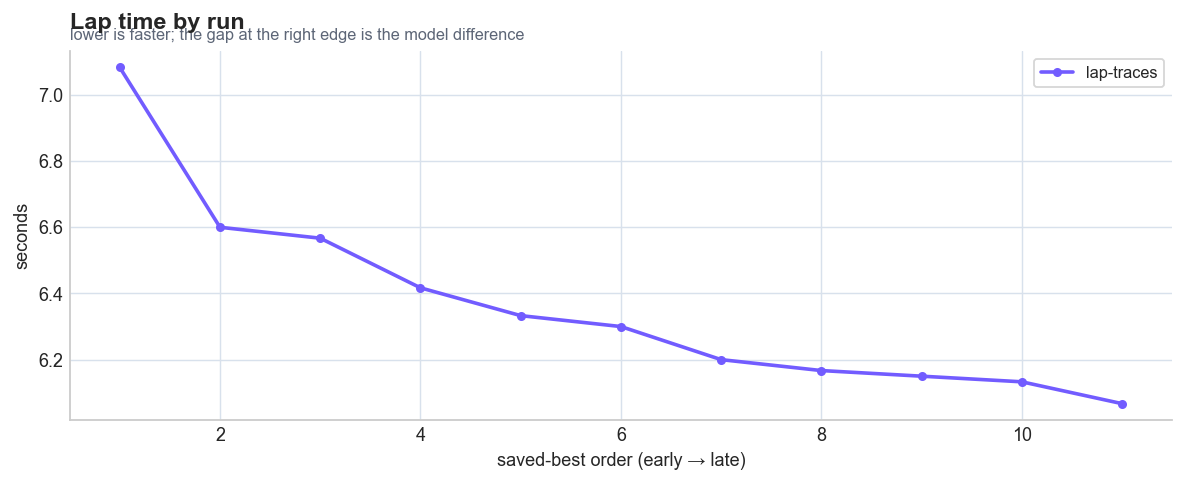

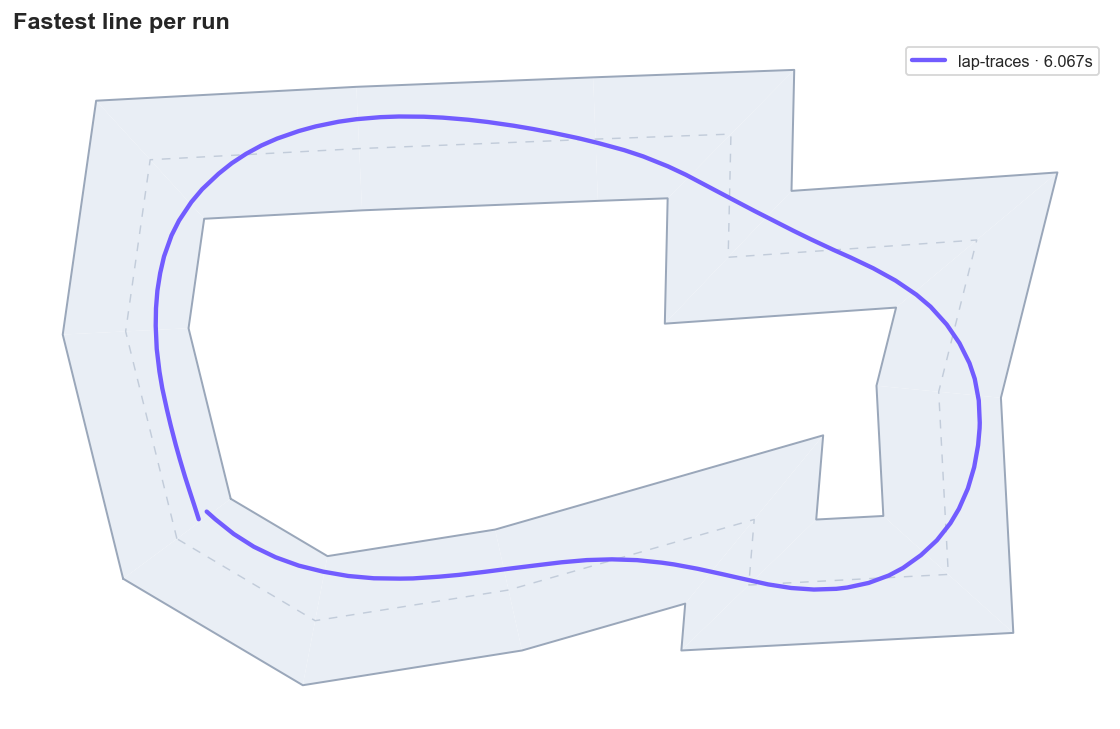

In [22]:
if RUNS and TRACK is not None:
    # 1) Lap time per run — is the new model actually quicker on the clock?
    fig, ax = plt.subplots(figsize=(9, 3.6), constrained_layout=True)
    for i, (name, traces) in enumerate(RUNS.items()):
        lap_times = [number(trace.get("lapTime")) for trace in traces]
        order = list(range(1, len(lap_times) + 1))
        ax.plot(order, lap_times, marker="o", markersize=4, linewidth=2,
                color=RUN_COLORS[i % len(RUN_COLORS)], label=legend_label(name))
    style_axis(ax, "Lap time by run", "lower is faster; the gap at the right edge is the model difference",
               xlabel="saved-best order (early → late)", ylabel="seconds")
    ax.legend(loc="best", frameon=True)
    plt.show()

    # 2) Fastest line per run on one track — the "better line, not just better clock" view.
    fig, ax = plt.subplots(figsize=(8.5, 6), constrained_layout=True)
    draw_track(ax, TRACK)
    for i, (name, traces) in enumerate(RUNS.items()):
        best = min(traces, key=lambda trace: number(trace.get("lapTime")) or math.inf)
        x, y = trace_xy(best)
        ax.plot(x, y, color=RUN_COLORS[i % len(RUN_COLORS)], linewidth=2.4, solid_capstyle="round",
                zorder=3 + i, label=f"{legend_label(name)} · {fmt(best.get('lapTime'), 3, 's')}")
    ax.set_title("Fastest line per run", loc="left", fontweight="bold")
    ax.legend(loc="best", frameon=True)
    plt.show()

    # 3) Side-by-side evolution so two models' learning paths sit next to each other.
    if len(RUNS) > 1:
        cols = len(RUNS)
        fig, axes = plt.subplots(1, cols, figsize=(6 * cols, 5), squeeze=False, constrained_layout=True)
        for ax, (name, traces) in zip(axes[0], RUNS.items()):
            plot_evolution(ax, TRACK, traces)
            ax.set_title(name, loc="left", fontweight="bold")
        plt.show()
else:
    display(Markdown("No runs to compare yet. Train at least one run with `npx tsx scripts/headless.ts`."))
